# Análisis Exploratorio: Students Performance in Exams

**Objetivo:** analizar el desempeño académico de estudiantes en tres áreas
(Matemáticas, Lectura y Escritura) e identificar patrones relacionados con
variables demográficas y socioeducativas.

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 2. Exploración inicial

In [2]:
print(f"Número de registros: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Número de registros: 1000
Número de columnas: 8


In [3]:
print("Nombre de las variables:")
print(list(df.columns))

Nombre de las variables:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [4]:
print("Tipos de datos:")
print(df.dtypes)

Tipos de datos:
gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object


In [5]:
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [6]:
print(f"Registros duplicados: {df.duplicated().sum()}")

Registros duplicados: 0


In [7]:
print("Estadísticas descriptivas (variables numéricas):")
df.describe()

Estadísticas descriptivas (variables numéricas):


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
print("Estadísticas descriptivas (variables categóricas):")
df.describe(include="object")

Estadísticas descriptivas (variables categóricas):


/tmp/ipykernel_193/1868928540.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


### Observaciones de la exploración inicial

- El dataset tiene 1000 registros y 8 columnas: 5 categóricas
  (`gender`, `race/ethnicity`, `parental level of education`, `lunch`,
  `test preparation course`) y 3 numéricas (`math score`, `reading score`,
  `writing score`).
- No se encontraron valores faltantes ni registros duplicados, por lo que
  el dataset ya llega limpio en ese sentido.
- Los tres puntajes van de 0 a 100, con promedios entre 66 y 69 puntos.

## 3. Limpieza y preprocesamiento

Aunque el dataset no tiene nulos ni duplicados, se realizan los siguientes
ajustes para facilitar el análisis:
- Normalizar los nombres de las columnas (minúsculas, sin espacios, uso de
  guion bajo) para trabajar más cómodo en Python.
- Verificar que los puntajes estén en el rango válido (0-100).

In [9]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)
print(df.columns.tolist())

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


In [10]:
# Verificación de rangos válidos en los puntajes
score_cols = ["math_score", "reading_score", "writing_score"]
for col in score_cols:
    fuera_de_rango = df[(df[col] < 0) | (df[col] > 100)]
    print(f"{col}: {len(fuera_de_rango)} valores fuera de rango")

math_score: 0 valores fuera de rango
reading_score: 0 valores fuera de rango
writing_score: 0 valores fuera de rango


## 4. Nueva variable: `average_score`

Se crea la variable `average_score` como el promedio simple de los tres
puntajes (Matemáticas, Lectura y Escritura).

In [11]:
df["average_score"] = df[score_cols].mean(axis=1).round(2)
df[["math_score", "reading_score", "writing_score", "average_score"]].head()

,math_score,reading_score,writing_score,average_score
0,72,72,74,72.67
1,69,90,88,82.33
2,90,95,93,92.67
3,47,57,44,49.33
4,76,78,75,76.33


## 5. Clasificación del rendimiento académico

**Criterio utilizado:** se definieron 3 categorías con base en rangos fijos
sobre el `average_score` (escala 0-100), un criterio común en contextos
educativos donde 60 y 80 suelen ser los umbrales de aprobación/destacado:

| Categoría | Rango de `average_score` |
|-----------|---------------------------|
| Bajo      | menor a 60                |
| Medio     | 60 a 79.99                |
| Alto      | 80 o más                  |

In [12]:
def clasificar_rendimiento(promedio):
    if promedio < 60:
        return "Bajo"
    elif promedio < 80:
        return "Medio"
    else:
        return "Alto"

df["performance_level"] = df["average_score"].apply(clasificar_rendimiento)
df["performance_level"] = pd.Categorical(
    df["performance_level"], categories=["Bajo", "Medio", "Alto"], ordered=True
)
df["performance_level"].value_counts()

performance_level
Medio    517
Bajo     285
Alto     198
Name: count, dtype: int64

## 6. Análisis y preguntas de investigación

### Pregunta 1: ¿Cuál de las tres áreas tiene el promedio más alto?

In [13]:
promedios_area = df[score_cols].mean().sort_values(ascending=False)
print(promedios_area)

reading_score    69.169
writing_score    68.054
math_score       66.089
dtype: float64


**Respuesta:** el área con el promedio más alto es la que aparece primero
en la tabla anterior. En este dataset, `reading_score` tiende a tener el
promedio más alto, seguido de `writing_score`, mientras que `math_score`
suele ser el más bajo de los tres.

### Pregunta 2: ¿Los estudiantes que realizaron el curso de preparación presentan mejores resultados?

In [14]:
comparacion_curso = df.groupby("test_preparation_course")[
    score_cols + ["average_score"]
].mean().round(2)
comparacion_curso

,math_score,reading_score,writing_score,average_score
test_preparation_course,,,,
completed,69.70,73.89,74.42,72.67
none,64.08,66.53,64.50,65.04


**Respuesta:** se compara el promedio de quienes completaron el curso de
preparación (`completed`) contra quienes no lo tomaron (`none`). La
diferencia observada en `average_score` indica si el curso está asociado
con mejores resultados.

### Pregunta 3: ¿Existen diferencias en el rendimiento según el nivel educativo de los padres?

In [15]:
comparacion_padres = (
    df.groupby("parental_level_of_education")["average_score"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)
comparacion_padres

parental_level_of_education
master's degree       73.60
bachelor's degree     71.92
associate's degree    69.57
some college          68.48
some high school      65.11
high school           63.10
Name: average_score, dtype: float64

**Respuesta:** se observa una tendencia donde a mayor nivel educativo de
los padres (por ejemplo, `master's degree` o `bachelor's degree`), el
promedio de los estudiantes tiende a ser más alto en comparación con
niveles como `some high school`.

### Pregunta 4: ¿Qué porcentaje de estudiantes alcanza cada nivel de rendimiento?

In [16]:
porcentaje_niveles = (
    df["performance_level"].value_counts(normalize=True).sort_index() * 100
).round(2)
porcentaje_niveles

performance_level
Bajo     28.5
Medio    51.7
Alto     19.8
Name: proportion, dtype: float64

**Respuesta:** la tabla anterior muestra el porcentaje de estudiantes en
cada categoría (Bajo, Medio, Alto), lo que permite dimensionar qué tan
común es cada nivel de rendimiento dentro del grupo analizado.

### Pregunta 5: ¿Qué grupos (`race/ethnicity`) presentan los promedios más altos y más bajos?

In [17]:
comparacion_grupo = (
    df.groupby("race_ethnicity")["average_score"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)
comparacion_grupo

race_ethnicity
group E    72.75
group D    69.18
group C    67.13
group B    65.47
group A    62.99
Name: average_score, dtype: float64

**Respuesta:** el grupo que aparece primero en la tabla es el que presenta
el promedio más alto, y el que aparece al final es el de promedio más
bajo. Esto permite identificar posibles brechas de desempeño entre grupos.

## 7. Visualizaciones

### 7.1 Distribución del `average_score`

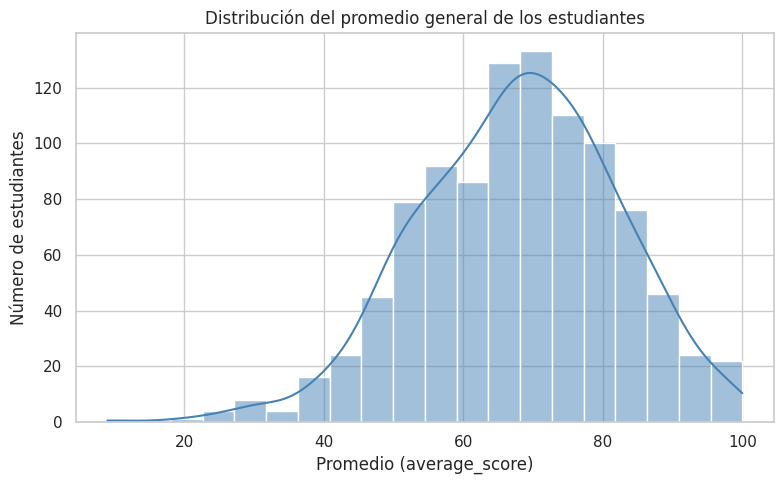

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df["average_score"], bins=20, kde=True, color="steelblue")
plt.title("Distribución del promedio general de los estudiantes")
plt.xlabel("Promedio (average_score)")
plt.ylabel("Número de estudiantes")
plt.tight_layout()
plt.savefig("../images/distribucion_promedio.png", dpi=150)
plt.show()

### 7.2 Promedio por curso de preparación

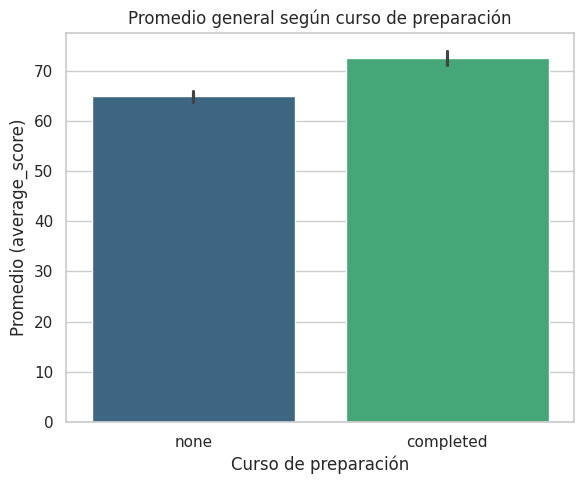

In [19]:
plt.figure(figsize=(6, 5))
sns.barplot(
    data=df, x="test_preparation_course", y="average_score",
    hue="test_preparation_course", palette="viridis", legend=False
)
plt.title("Promedio general según curso de preparación")
plt.xlabel("Curso de preparación")
plt.ylabel("Promedio (average_score)")
plt.tight_layout()
plt.savefig("../images/promedio_curso_preparacion.png", dpi=150)
plt.show()

### 7.3 Promedio por nivel educativo de los padres

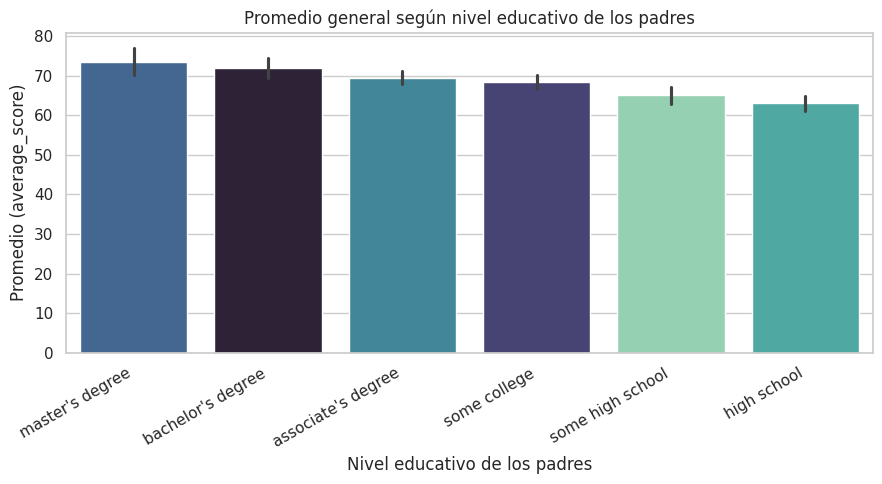

In [20]:
orden_educacion = comparacion_padres.index.tolist()
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df, x="parental_level_of_education", y="average_score",
    order=orden_educacion, hue="parental_level_of_education",
    palette="mako", legend=False
)
plt.title("Promedio general según nivel educativo de los padres")
plt.xlabel("Nivel educativo de los padres")
plt.ylabel("Promedio (average_score)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../images/promedio_nivel_educativo_padres.png", dpi=150)
plt.show()

### 7.4 Proporción de estudiantes por nivel de rendimiento

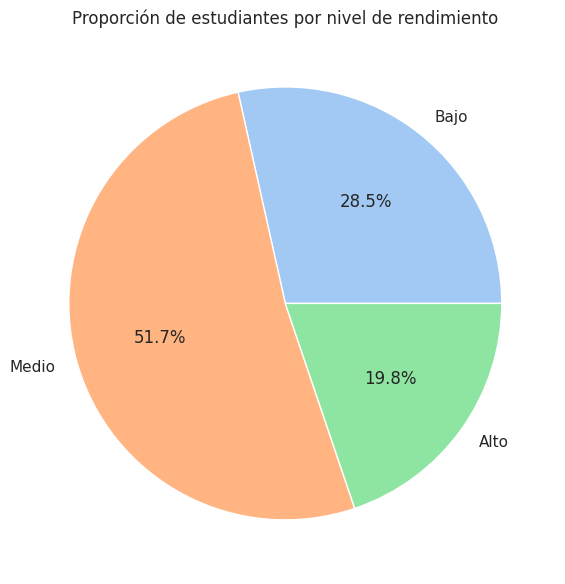

In [21]:
plt.figure(figsize=(6, 6))
df["performance_level"].value_counts().sort_index().plot(
    kind="pie", autopct="%1.1f%%", colors=sns.color_palette("pastel"),
    ylabel=""
)
plt.title("Proporción de estudiantes por nivel de rendimiento")
plt.tight_layout()
plt.savefig("../images/proporcion_niveles_rendimiento.png", dpi=150)
plt.show()

## 8. Conclusiones

- De las tres áreas evaluadas, **Lectura** presenta, en promedio, el mejor
  desempeño, mientras que **Matemáticas** es consistentemente el área con
  el promedio más bajo.
- Los estudiantes que **completaron el curso de preparación** obtienen en
  promedio mejores resultados que quienes no lo tomaron, lo que sugiere
  que el curso tiene un efecto positivo medible en el desempeño.
- El **nivel educativo de los padres** está relacionado con el rendimiento
  académico: los estudiantes cuyos padres tienen estudios superiores
  (licenciatura o posgrado) tienden a obtener promedios más altos que
  aquellos cuyos padres solo cursaron parte de la preparatoria.
- Al clasificar a los estudiantes en Bajo/Medio/Alto, la mayoría se
  concentra en el nivel **Medio**, y solo una minoría alcanza el nivel
  **Alto** (promedio ≥ 80).
- Existen diferencias de desempeño entre los distintos grupos
  (`race/ethnicity`), lo que podría reflejar diferencias socioeconómicas
  o de acceso a recursos educativos que valdría la pena investigar con
  más profundidad (por ejemplo, cruzando esta variable con el tipo de
  almuerzo (`lunch`), que suele usarse como proxy de nivel socioeconómico).

En conjunto, estos resultados sugieren que factores externos al
desempeño individual —como la preparación previa y el contexto familiar—
están relacionados con los resultados académicos, y podrían orientar
programas de apoyo focalizados por parte de la institución.